In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer(as_frame=True)

df = data.frame.copy()

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
print(data.target_names)

['malignant' 'benign']


In [6]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (455, 30)
Scaled testing data shape: (114, 30)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [10]:
# Create the five classification models

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "kNN": KNeighborsClassifier(n_neighbors=5),
    
    "Naive Bayes": GaussianNB(),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

print("Models created successfully:")
for name in models:
    print("-", name)

Models created successfully:
- Logistic Regression
- Decision Tree
- kNN
- Naive Bayes
- Random Forest


In [11]:
max_iter=5000

In [12]:
n_neighbors=5

In [13]:
n_estimators=200

In [14]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
kNN trained successfully
Naive Bayes trained successfully
Random Forest trained successfully


In [15]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

results = {}

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability for AUC
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

print("Evaluation completed successfully!")

Evaluation completed successfully!


In [16]:
results_df = pd.DataFrame(results).T

results_df = results_df.round(4)

results_df

,Accuracy,AUC,Precision,Recall,F1 Score,MCC
Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
Decision Tree,0.9123,0.9157,0.9559,0.9028,0.9286,0.8174
kNN,0.9561,0.9788,0.9589,0.9722,0.9655,0.9054
Naive Bayes,0.9298,0.9868,0.9444,0.9444,0.9444,0.8492
Random Forest,0.9561,0.9932,0.9589,0.9722,0.9655,0.9054



Logistic Regression
[[41  1]
 [ 1 71]]


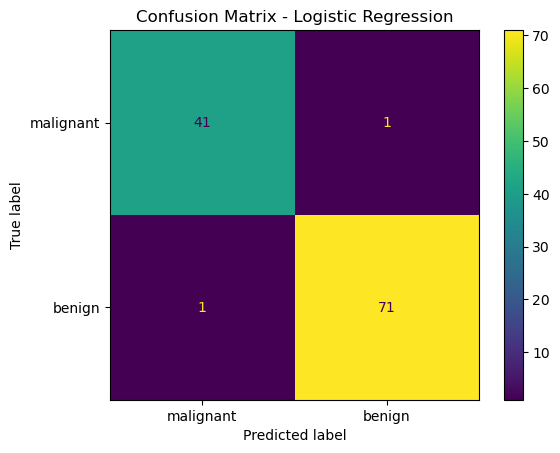


Decision Tree
[[39  3]
 [ 7 65]]


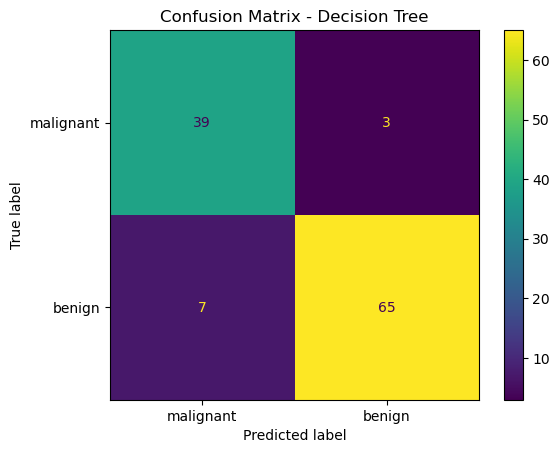


kNN
[[39  3]
 [ 2 70]]


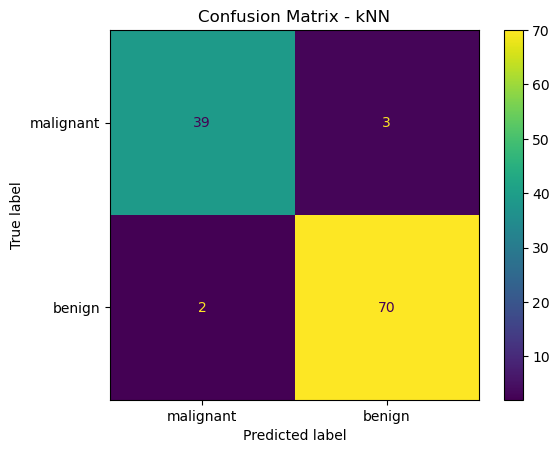


Naive Bayes
[[38  4]
 [ 4 68]]


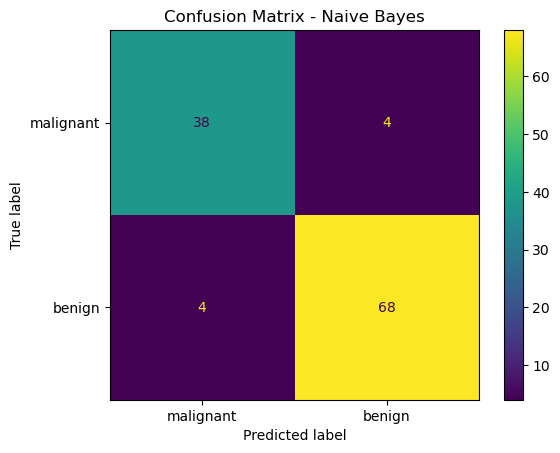


Random Forest
[[39  3]
 [ 2 70]]


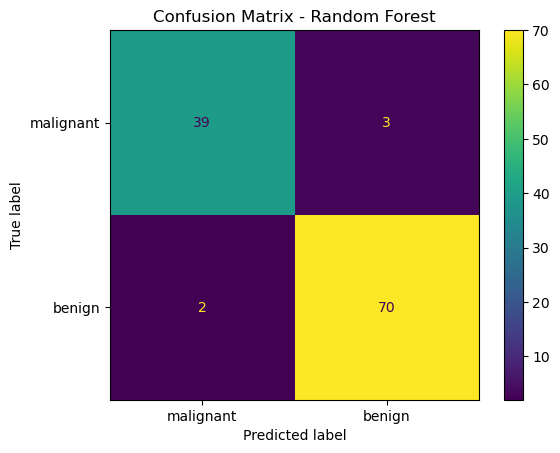

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=data.target_names
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [18]:
results_df.to_csv("results_summary.csv", index=True)

print("Results saved successfully!")

Results saved successfully!


In [19]:
test_df = X_test.copy()
test_df["target"] = y_test.values

test_df.to_csv("test_data.csv", index=False)

print("Test data saved successfully!")
print("Test data shape:", test_df.shape)

Test data saved successfully!
Test data shape: (114, 31)


In [20]:
import os
import joblib

os.makedirs("model", exist_ok=True)

In [21]:
for name, model in models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    joblib.dump(model, f"model/{filename}.pkl")

print("All models saved successfully!")

All models saved successfully!


In [22]:
joblib.dump(scaler, "model/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!
